# Getting Started in Dynestyx

Dynestyx is a probabilistic programming language package that incorporates dynamical systems. 

Models are defined as simple probabilistic programs.

In [1]:
def continuous_time_stochastic_l63_model():
    """Model that samples drift parameter rho and uses it in dynamics."""
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0))

    # Create the dynamical model with sampled rho
    dynamics = DynamicalModel(
        state_dim=3,
        observation_dim=1,
        initial_condition=dist.MultivariateNormal(
            loc=jnp.zeros(3), covariance_matrix=20.0**2 * jnp.eye(3)
        ),
        state_evolution=ContinuousTimeStateEvolution(
            drift=lambda x, u, t: jnp.array(
                [
                    10.0 * (x[1] - x[0]),
                    x[0] * (rho - x[2]) - x[1],
                    x[0] * x[1] - (8.0 / 3.0) * x[2],
                ]
            ),
            diffusion_coefficient=lambda x, u, t: jnp.eye(3),
            diffusion_covariance=lambda x, u, t: jnp.eye(3),
        ),
        observation_model=LinearGaussianObservation(
            H=jnp.array([[1.0, 0.0, 0.0]]), R=jnp.array([[5.0**2]])
        ),
    )

    # TODO: observation_model should simply be dist.MultivariateNormal(...) here,
    # but for now we wrap it in LinearGaussianObservation for so that we can extract
    # H and R later for CD-Dynamax conversion (structure exploiting algorithms).
    # In the future, we will build internal logic to identify linear-gaussian observation models
    # and extract H, R automatically.

    # TODO: Functions for drift, diffusion_coefficient, diffusion_covariance should not
    # require (x, u, t) arguments if they are not used. We can wrap them internally.
    # e.g. diffusion_coefficient=jnp.eye(3)
    # e.g. drift = lambda x: F(x, rho)

    # Return a sampled dynamical model, named "f".
    return sample_ds("f", dynamics)

To generate observations, we use standard `numpyro` tools. In particular, we use a `predictive` over the model.

In [2]:
from numpyro.infer import Predictive
import jax.random as jr
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from dsx.dynamical_models import DynamicalModel, ContinuousTimeStateEvolution
from dsx.observations import LinearGaussianObservation
from dsx.ops import sample_ds
from dsx.handlers import Condition
from dsx.ops import Trajectory, Context
from dsx.solvers import SDESolver

from effectful.ops.semantics import handler


data_init_key, data_solver_key, mcmc_key, posterior_pred_key = jr.split(jr.PRNGKey(0), 4)

# Set true parameters for synthetic data generation
true_rho = 28.0

# ---------------------------------------------------------
# Generate synthetic observations using Predictive
# ---------------------------------------------------------
# Generate observations at some times
obs_times = jnp.arange(start=0.0, stop=20.0, step=0.01)

# Generate synthetic data
true_params = {"rho": jnp.array(true_rho)}
predictive = Predictive(
    continuous_time_stochastic_l63_model,
    params=true_params,
    num_samples=1,
    exclude_deterministic=False,
)

context = Context(observations=Trajectory(times=obs_times))
with handler(SDESolver(key=data_solver_key)):
    with handler(Condition(context)):
        synthetic = predictive(data_init_key)

/home/dwaxman/devel/dynestyx/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dwaxman/devel/dynestyx/dsx/dynamical_models.py:53: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


This generates data from the generative model.

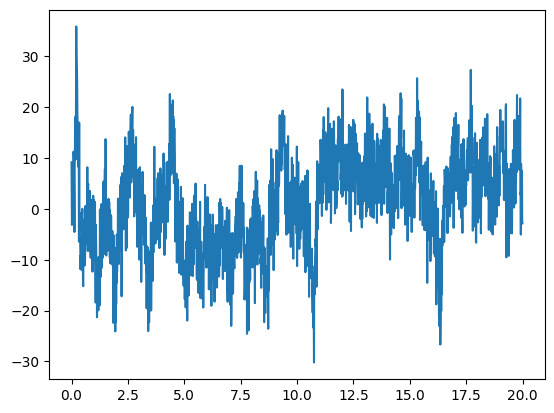

In [3]:
import matplotlib.pyplot as plt

plt.plot(obs_times, synthetic["observations"].squeeze(0))
plt.show()


In [4]:
# To obtain log-likelihoods, we can use the `FilterBasedMarginalLogLikelihood` handler.
from dsx.filters import (
    FilterBasedMarginalLogLikelihood,
)

obs_values = synthetic["observations"].squeeze(0)  # shape (T, obs_dim)

# ---------------------------------------------------------
# Build conditioned model
# ---------------------------------------------------------
observation_trajectory = Trajectory(times=obs_times, values=obs_values)

def data_conditioned_model():
    context = Context(observations=observation_trajectory)
    with handler(FilterBasedMarginalLogLikelihood()):
        with handler(Condition(context)):
            return continuous_time_stochastic_l63_model()


Inference is then easy, again, using standard `numpyro`.

In [5]:
import arviz as az
from numpyro.infer import MCMC, NUTS

mcmc_key = jr.PRNGKey(0)
nuts_kernel = NUTS(data_conditioned_model)
mcmc = MCMC(nuts_kernel, num_samples=100, num_warmup=100)
mcmc.run(mcmc_key)

posterior_samples = mcmc.get_samples()

/home/dwaxman/devel/dynestyx/dsx/dynamical_models.py:53: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(
sample: 100%|██████████| 200/200 [01:25<00:00,  2.34it/s, 3 steps of size 5.39e-01. acc. prob=0.96] 


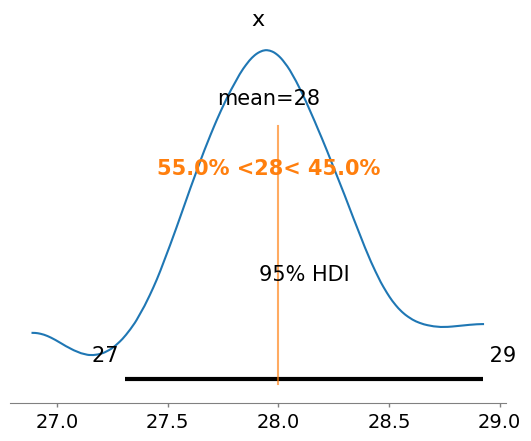

In [6]:
posterior_rho = posterior_samples["rho"]

az.plot_posterior(
    posterior_rho, hdi_prob=0.95, ref_val=true_params["rho"].item()
)

plt.show()